<a href="https://colab.research.google.com/github/arsucoder/Loan-default-prediction/blob/main/Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem

For financial institutions, the ability to predict loan defaults is a critical factor in managing financial risk, maintaining profitability, and ensuring sustainable growth. Defaulted loans can significantly disrupt the financial health of an institutions, as they lead to substantial losses and may potentially affect the institution's credibility.

# Expected Solution

For the given Test dataset, a ML Model needs to predict the class of a borrower defaulting or not defaulting on a loan (1 or 0 Class).

# Approach

* Data cleaning
* Feature Engineering to remove less related columns
* Undersampling the test dataset to balance 0 and 1 class
* Developing Classification Pipeline For Splitting and model training
* Evaluation and comparison of different Models
* Hypertuning of Base Model to Get best parameters
* Saving the best Model
* Saving the Predictions on new Dataset if Provided

In [ ]:
import tensorflow as tf

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import iplot
from plotly.subplots import make_subplots

In [ ]:
df = pd.read_csv('/content/Loan_default.csv')

In [ ]:
# Check Dataset

print('### first 5 lines ###','\n')
df.head().T

### first 5 lines ### 



,0,1,2,3,4
LoanID,I38PQUQS96,HPSK72WA7R,C1OZ6DPJ8Y,V2KKSFM3UN,EY08JDHTZP
Age,56,69,46,32,60
Income,85994,50432,84208,31713,20437
LoanAmount,50587,124440,129188,44799,9139
CreditScore,520,458,451,743,633
MonthsEmployed,80,15,26,0,8
NumCreditLines,4,1,3,3,4
InterestRate,15.23,4.81,21.17,7.07,6.51
LoanTerm,36,60,24,24,48
DTIRatio,0.44,0.68,0.31,0.23,0.73


# Inspecting and Cleaning Dataframe structure

In [ ]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (255347, 18)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
LoanID,object,0,0.0,0,255347,255347,NaN,NaN,NaN,NaN,I38PQUQS96,HPSK72WA7R,C1OZ6DPJ8Y
Age,int64,0,0.0,0,52,255347,18.0,69.0,43.498306,14.990258,56,69,46
Income,int64,0,0.0,0,114620,255347,15000.0,149999.0,82499.304597,38963.013729,85994,50432,84208
LoanAmount,int64,0,0.0,0,158729,255347,5000.0,249999.0,127578.865512,70840.706142,50587,124440,129188
CreditScore,int64,0,0.0,0,550,255347,300.0,849.0,574.264346,158.903867,520,458,451
MonthsEmployed,int64,0,0.0,0,120,255347,0.0,119.0,59.541976,34.643376,80,15,26
NumCreditLines,int64,0,0.0,0,4,255347,1.0,4.0,2.501036,1.117018,4,1,3
InterestRate,float64,0,0.0,0,2301,255347,2.0,25.0,13.492773,6.636443,15.23,4.81,21.17
LoanTerm,int64,0,0.0,0,5,255347,12.0,60.0,36.025894,16.96933,36,60,24
DTIRatio,float64,0,0.0,0,81,255347,0.1,0.9,0.500212,0.230917,0.44,0.68,0.31


In [ ]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [ ]:
df['Default'].value_counts()

,count
Default,
0,225694
1,29653


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

In [ ]:
num_cols

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Default']

# Plotting all the num_cols for visualising

Age


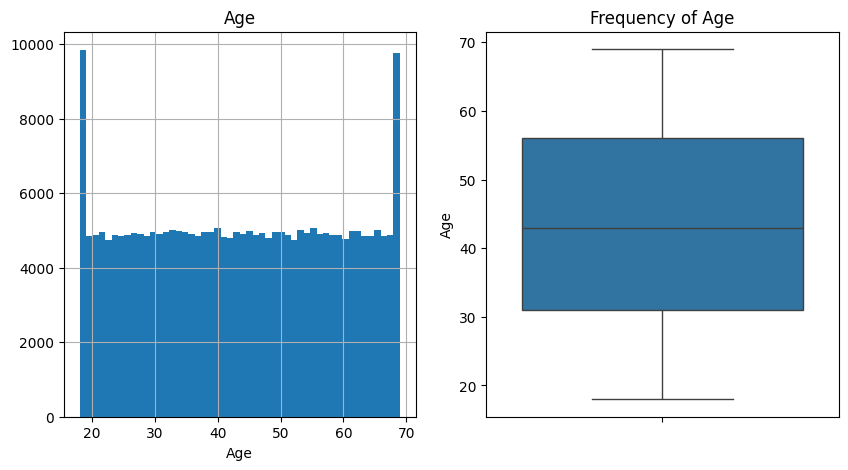

______________________________________________________

Income


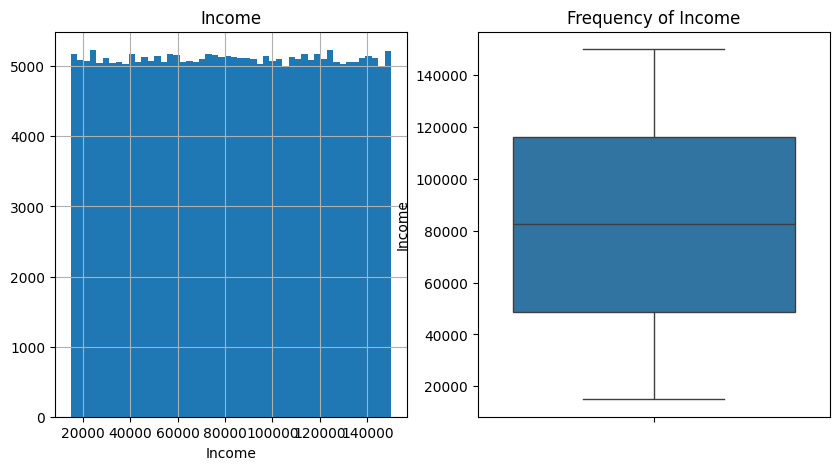

______________________________________________________

LoanAmount


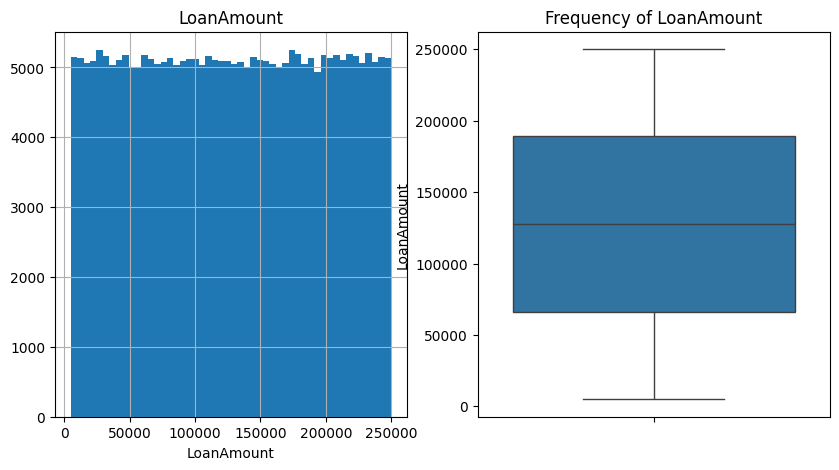

______________________________________________________

CreditScore


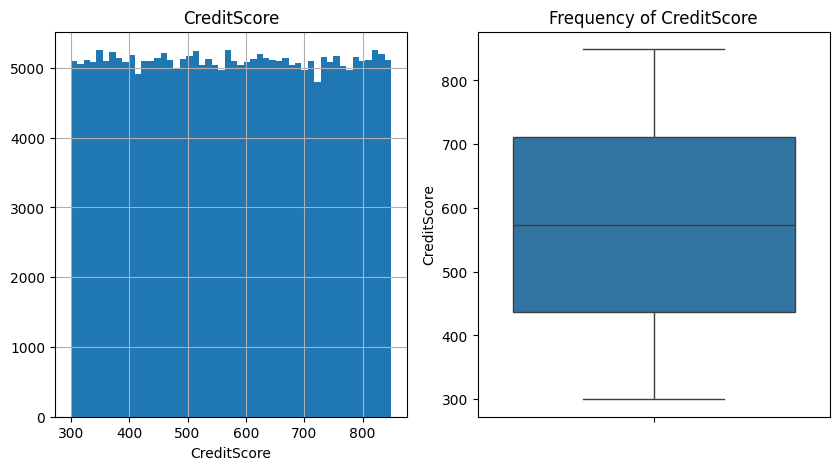

______________________________________________________

MonthsEmployed


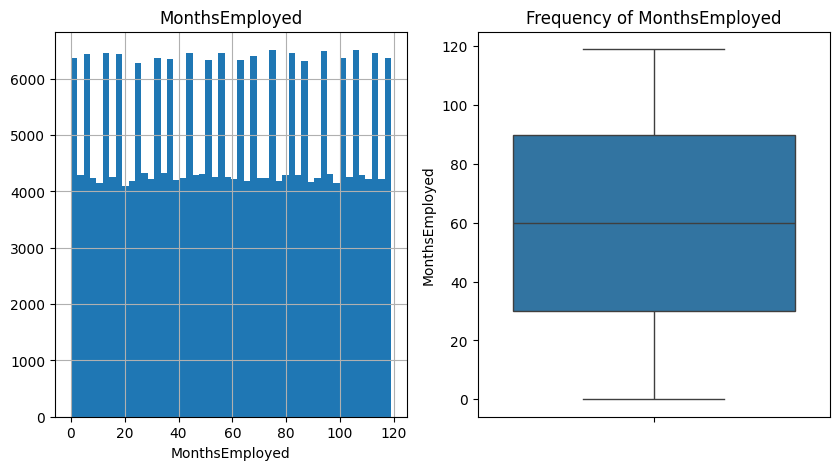

______________________________________________________

NumCreditLines


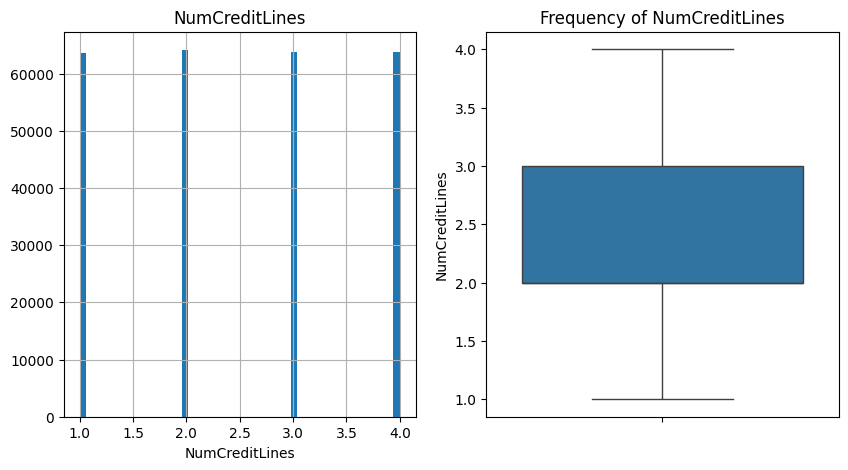

______________________________________________________

InterestRate


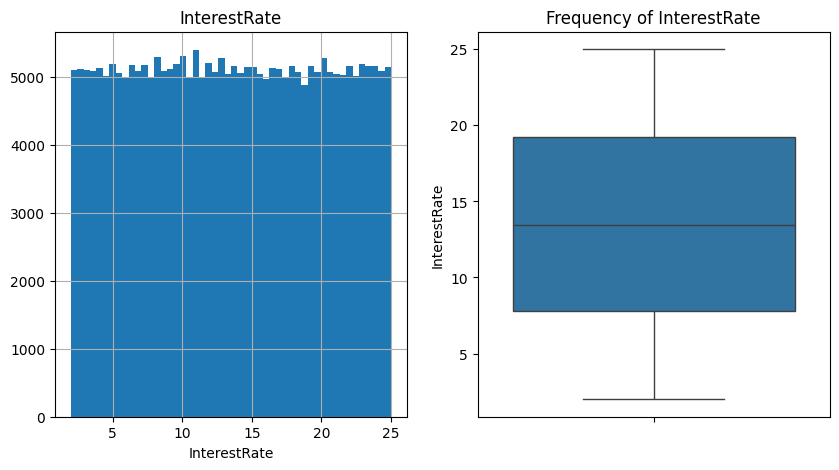

______________________________________________________

LoanTerm


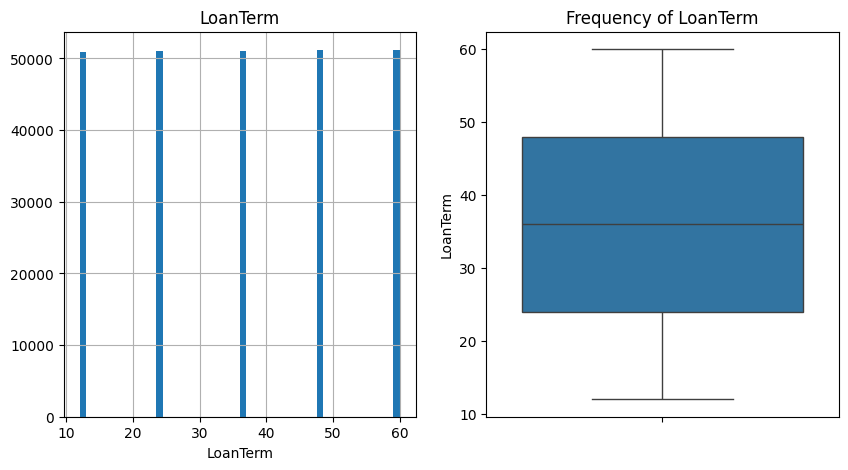

______________________________________________________

DTIRatio


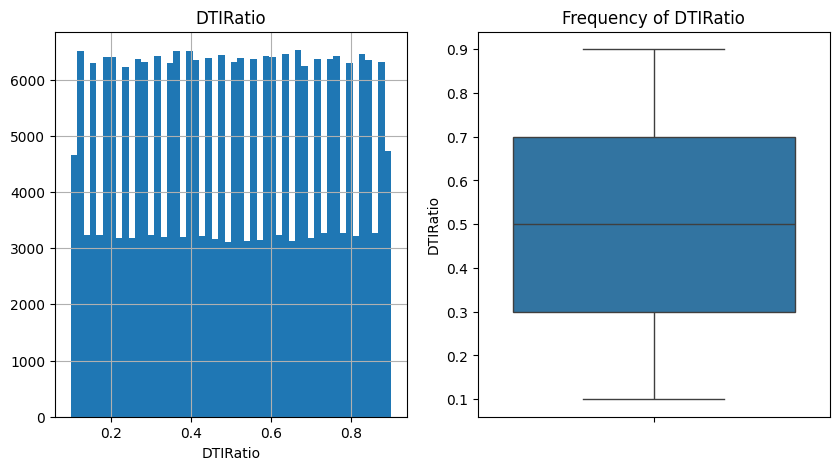

______________________________________________________

Default


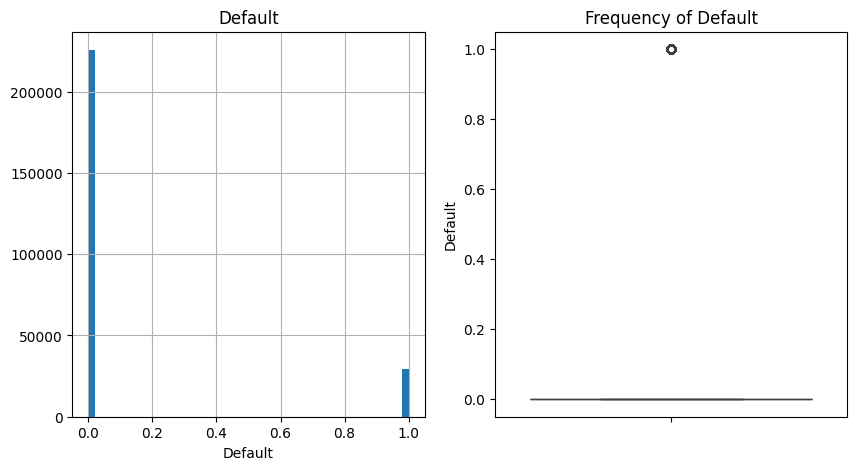

______________________________________________________



In [ ]:
def num_summary(dataframe, numerical_col, plot=False):
    #quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    #print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
            fig, axs = plt.subplots(1, 2, figsize=(10, 5))
            plt.subplot(1, 2, 1)
            dataframe[numerical_col].hist(bins=50)
            plt.xlabel(numerical_col)
            plt.title(numerical_col)

            plt.subplot(1, 2, 2)
            sns.boxplot(y=numerical_col, data=dataframe)
            plt.title("Frequency of " + numerical_col)
            plt.xticks(rotation=90)

            plt.show(block=True)

            print("______________________________________________________\n")

for col in num_cols:
    print(col)
    num_summary(df, col, plot=True)

In [ ]:
len(num_cols), len(df.columns)

(10, 18)

# Removing the Outliers from Numerical columns

In [ ]:
na_cols = df.columns[df.isna().all()]
num_na_cols = len(na_cols)
print(f"Number of columns with only NA values: {num_na_cols}")

Number of columns with only NA values: 0


In [ ]:
df[num_cols].isna().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0
Default,0


In [ ]:
to_drop = ["Score_Source_1", "Social_Circle_Default", "Own_House_Age"]
to_drop_2 = ["Client_Occupation", "Score_Source_3"]

In [ ]:
df = df.drop(to_drop_2, axis=1, errors='ignore')

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
replace_with_mean = ["Child_Count", "Client_Family_Members", "Cleint_City_Rating",
                     "Application_Process_Day", "Application_Process_Hour", "Credit_Bureau"]

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
def remove_outliers(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  df_out = df[(df[col] > lower_bound) & (df[col] < upper_bound)]
  return df_out

In [ ]:
def remove_missing_values(df, col):
  df = df.dropna(subset=[col])
  return df

In [ ]:
def replace_missing_with_mean(df, col):
  df[col] = df[col].fillna(df[col].mean())
  return df

# The process of cleaning the data-

* First remove the outliers
* Fill the NA values with mean wherever possible
* Remove all missing value columns then.

In [ ]:
columns_to_impute = [col for col in replace_with_mean if col in df.columns]
for col in columns_to_impute:
    df = replace_missing_with_mean(df, col)


In [ ]:
df.shape

(255347, 18)

In [ ]:
for col in df.columns:
  df = remove_missing_values(df, col)

In [ ]:
df.isna().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.shape

(255347, 18)

In [ ]:
df["Default"].value_counts()

,count
Default,
0,225694
1,29653


In [ ]:
df.isna().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [ ]:
def balance_dataset(df, target_col):
  class_0 = df[df[target_col] == 0]
  class_1 = df[df[target_col] == 1]

  sample_size = min(len(class_0), len(class_1))

  balanced_df = pd.concat([class_0.sample(sample_size), class_1.sample(sample_size)])

  return balanced_df.sample(frac=1)

df_train = balance_dataset(df, 'Default')

In [ ]:
df_train.shape

(59306, 18)

In [ ]:
df_train["Default"].value_counts()

,count
Default,
0,29653
1,29653


Pipeline of model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with one-hot encoding
def random_forest_pipeline(df, target_column, categorical_columns):
    # Step 1: Data preparation
    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(), categorical_columns),
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])
        ]
    )

    # Step 4: Define Random Forest pipeline
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    rf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = rf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        return rf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return rf_pipeline, predict_new_data

# Example usage of the function
# df = pd.read_csv('your_data.csv')  # Load your dataset
# categorical_columns = ['col1', 'col2']  # Specify your categorical columns
# rf_model, predict_new_data = random_forest_pipeline(df, 'target', categorical_columns)  # Replace 'target' with your actual target column

# Making predictions on new data
# new_data = pd.DataFrame(...)  # Load or create new data to predict on
# predictions = predict_new_data(new_data)
# print(predictions)

In [ ]:
import numpy as np
cat_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()
print(cat_cols)

['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


# Random Forest Pipeline

* Only for Random Forest classifier model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with type consistency and one-hot encoding
def random_forest_pipeline_2(df, target_column, categorical_columns):
    # Step 1: Data preparation
    # Ensure that all categorical columns have consistent string data types
    for col in categorical_columns:
        df[col] = df[col].astype(str)

    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),  # One-hot encoding for categorical columns
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])  # Scaling numerical columns
        ]
    )

    # Step 4: Define Random Forest pipeline
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    rf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = rf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        # Convert categorical columns to strings before prediction
        for col in categorical_columns:
            new_data[col] = new_data[col].astype(str)
        return rf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return rf_pipeline, predict_new_data, y_pred

# Example usage of the function
# df = pd.read_csv('your_data.csv')  # Load your dataset
# categorical_columns = ['col1', 'col2']  # Specify your categorical columns
# rf_model, predict_new_data = random_forest_pipeline(df, 'target', categorical_columns)  # Replace 'target' with your actual target column

# Making predictions on new data
# new_data = pd.DataFrame(...)  # Load or create new data to predict on
# predictions = predict_new_data(new_data)
# print(predictions)

# Classification Pipeline

* Trying 3 different models to choose best model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with type consistency, one-hot encoding, and multiple model options
def classification_pipeline(df, target_column, categorical_columns, model):
    # Step 1: Data preparation
    # Ensure that all categorical columns have consistent string data types
    for col in categorical_columns:
        df[col] = df[col].astype(str)

    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),  # One-hot encoding for categorical columns
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])  # Scaling numerical columns
        ]
    )

    # Step 4: Define the classification pipeline with the selected model
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(clf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    clf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = clf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        # Convert categorical columns to strings before prediction
        for col in categorical_columns:
            new_data[col] = new_data[col].astype(str)
        return clf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return clf_pipeline, predict_new_data, y_pred, y_test

Cross-Validation Accuracy Scores: [0.66835283 0.65886816 0.66445358 0.66677205 0.66779089]
Mean Cross-Validation Accuracy: 0.6652475032330859
Test Accuracy: 0.667256786376665

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.68      0.67      5931
           1       0.67      0.66      0.66      5931

    accuracy                           0.67     11862
   macro avg       0.67      0.67      0.67     11862
weighted avg       0.67      0.67      0.67     11862


Confusion Matrix:
[[4011 1920]
 [2027 3904]]


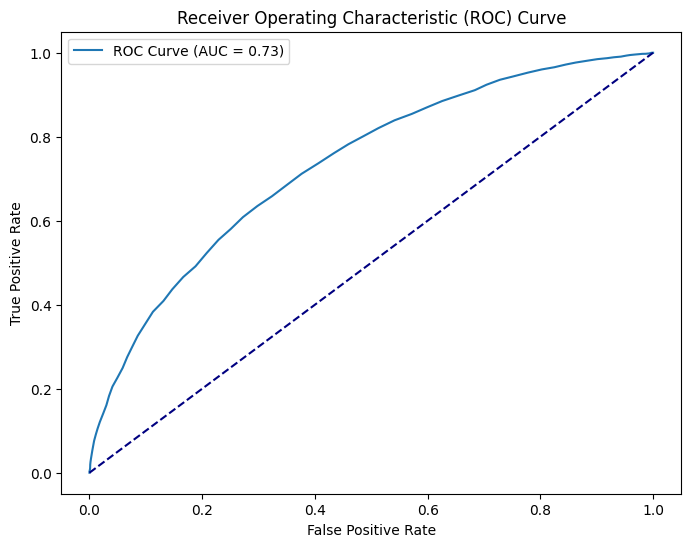

In [ ]:
# Using RandomForest
rf_model, predict_new_data_rf, rf_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, RandomForestClassifier(random_state=42))

Cross-Validation Accuracy Scores: [0.68173675 0.67583518 0.67889135 0.68152598 0.67169056]
Mean Cross-Validation Accuracy: 0.6779359614407523
Test Accuracy: 0.6829371100994773

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68      5931
           1       0.68      0.69      0.69      5931

    accuracy                           0.68     11862
   macro avg       0.68      0.68      0.68     11862
weighted avg       0.68      0.68      0.68     11862


Confusion Matrix:
[[3982 1949]
 [1812 4119]]


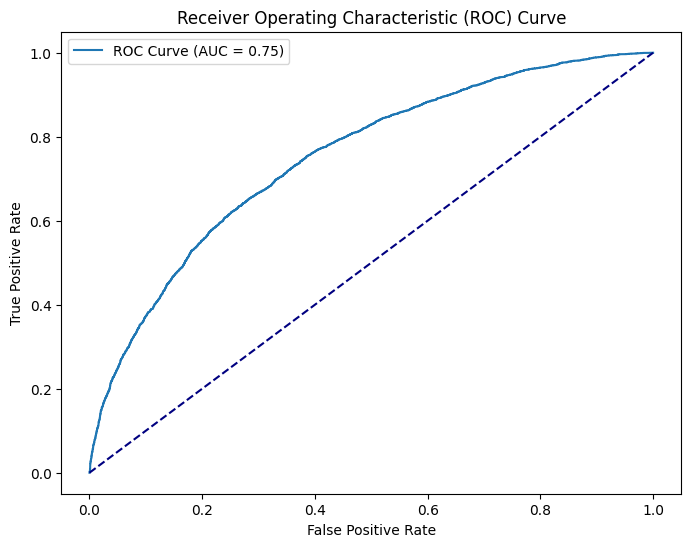

In [ ]:
# Using Logistic Regression
lr_model, predict_new_data_lr, lr_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, LogisticRegression(max_iter=1000))

In [ ]:
def evaluate_model(model, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [ ]:
def compare_models(y_test, gb_predictions, lr_predictions, rf_predictions):
  models = [gb_model, lr_model, rf_model]
  predictions = [gb_predictions, lr_predictions, rf_predictions]
  accuracies = []

  for model, pred in zip(models, predictions):
    accuracies.append(evaluate_model(model, y_test, pred))
    return accuracies

Cross-Validation Accuracy Scores: [0.68668985 0.67868058 0.67773211 0.68521446 0.67917369]
Mean Cross-Validation Accuracy: 0.6814981383431992
Test Accuracy: 0.6855504973866127

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.69      5931
           1       0.69      0.68      0.68      5931

    accuracy                           0.69     11862
   macro avg       0.69      0.69      0.69     11862
weighted avg       0.69      0.69      0.69     11862


Confusion Matrix:
[[4079 1852]
 [1878 4053]]


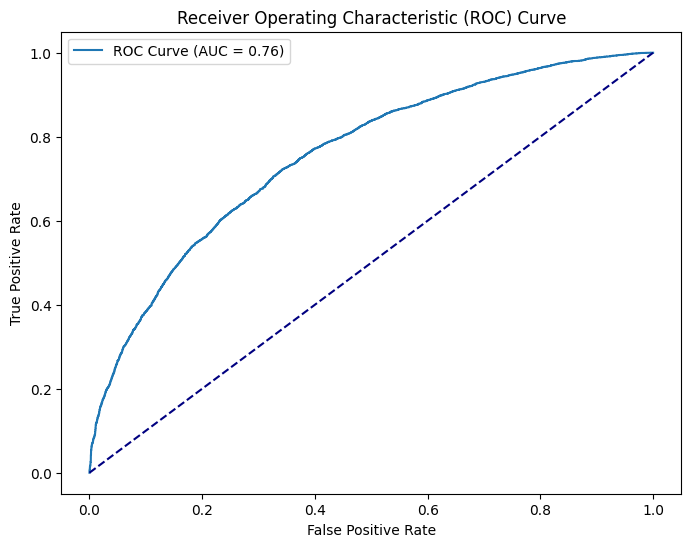

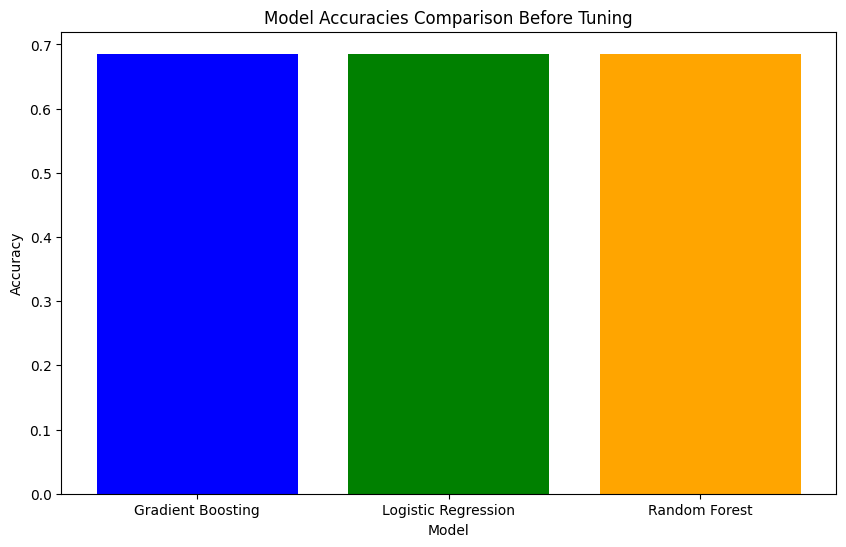

In [ ]:
gb_model, predict_new_data_gb, gb_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, GradientBoostingClassifier(random_state=42))

# Plotting the accuracies
accuracies = compare_models(y_test, gb_predictions, lr_predictions, rf_predictions)
models = ['Gradient Boosting', 'Logistic Regression', 'Random Forest']
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracies Comparison Before Tuning')
plt.show()

In [ ]:
X = df_train.drop(columns=['Default'])
y = df_train['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Tuning rf forest classifier

from sklearn.model_selection import GridSearchCV

def tune_random_forest(X_train, y_train):
    # Define the parameter grid for grid search
    param_grid = {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__max_depth': [None, 20, 30],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__bootstrap': [True, False]
    }


    rf = rf_model
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Random Forest:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_

In [ ]:
# For logistics Regression



def tune_logistic_regression(X_train, y_train):
    param_grid = {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear'],
        'classifier__penalty': ['l2'],
        'classifier__max_iter': [200, 500]
    }
    lr = lr_model
    grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Logistic Regression:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_

In [ ]:
# For GradientBoostingClassifier

def tune_gradient_boosting(X_train, y_train):
    param_grid = {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__learning_rate': [0.1, 0.05],
        'classifier__max_depth': [5, 8],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__subsample': [1.0]
    }
    gb = gb_model
    grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Gradient Boosting:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_

# From Rf Classifier

* Best parameters for Random Forest: {'classifier__bootstrap': True, 'classifier__max_depth': 30, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
* Best cross-validation accuracy: 0.6575842696629214

# From LR classifier

* Best parameters for Logistic Regression: {'classifier__C': 0.1, 'classifier__max_iter': 200, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
* Best cross-validation accuracy: 0.6394535240040857

# From Gradient Booster

* Best parameters for Gradient Boosting: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
* Best cross-validation accuracy: 0.628140960163432

# Uncomment these lines when you need to tune the model as its time taking

In [ ]:
# tune_random_forest(X_train, y_train)

In [ ]:
# tune_logistic_regression(X_train, y_train)

In [ ]:
# tune_gradient_boosting(X_train, y_train)

# Comparison of accuracies after tuning the models

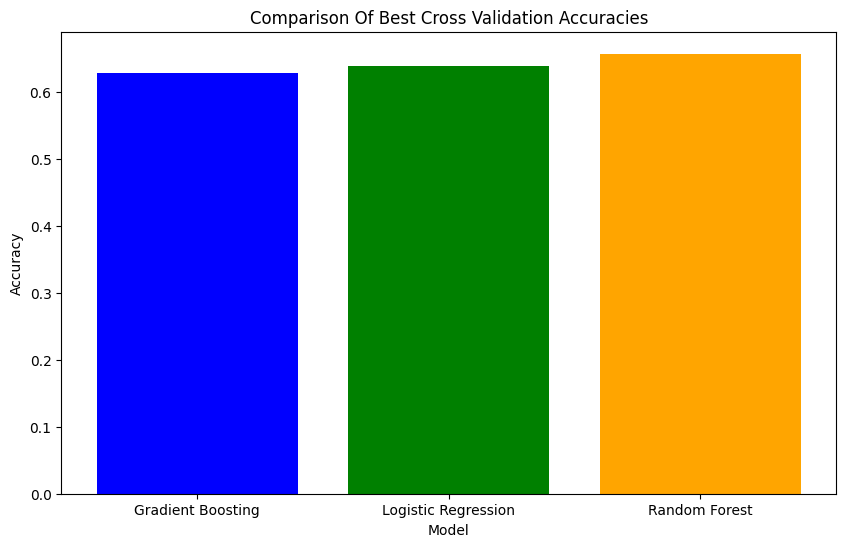

In [ ]:
best_cv_accuracy = [0.628140960163432, 0.6394535240040857, 0.6575842696629214]

plt.figure(figsize=(10, 6))
plt.bar(models, best_cv_accuracy, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison Of Best Cross Validation Accuracies')
plt.show()

# Put Best params model in classification pipeline to get report over it

Cross-Validation Accuracy Scores: [0.67298978 0.65855201 0.66529666 0.67046053 0.66273187]
Mean Cross-Validation Accuracy: 0.6660061699203677
Test Accuracy: 0.6663294554038105

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.66      0.66      5931
           1       0.66      0.67      0.67      5931

    accuracy                           0.67     11862
   macro avg       0.67      0.67      0.67     11862
weighted avg       0.67      0.67      0.67     11862


Confusion Matrix:
[[3910 2021]
 [1937 3994]]


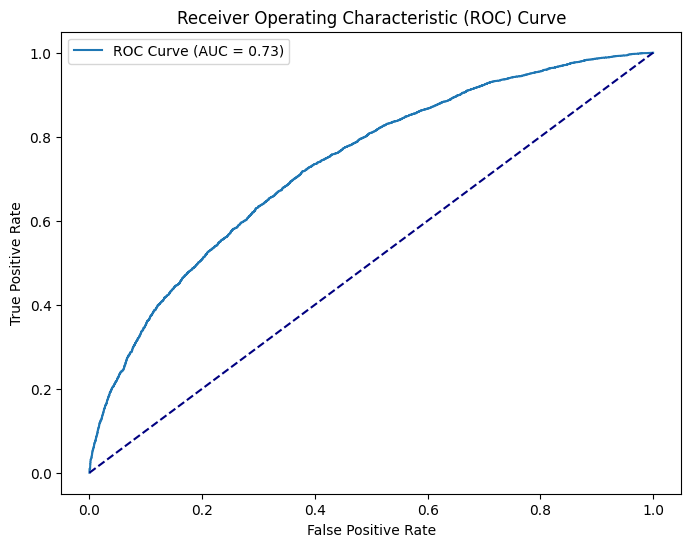

In [ ]:
rf_tuned_model, predict_new_data_rf_tuned, rf_predictions_tuned, y_test = classification_pipeline(df_train, 'Default', cat_cols, RandomForestClassifier(random_state=42,
                                                                                                                                                        n_estimators=100,
                                                                                                                                                        max_depth= 30,
                                                                                                                                                        min_samples_leaf= 1,
                                                                                                                                                        min_samples_split=5))

Cross-Validation Accuracy Scores: [0.68289598 0.67246285 0.67846981 0.68099905 0.67537943]
Mean Cross-Validation Accuracy: 0.6780414243740467
Test Accuracy: 0.6809981453380543

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.68      5931
           1       0.68      0.68      0.68      5931

    accuracy                           0.68     11862
   macro avg       0.68      0.68      0.68     11862
weighted avg       0.68      0.68      0.68     11862


Confusion Matrix:
[[4065 1866]
 [1918 4013]]


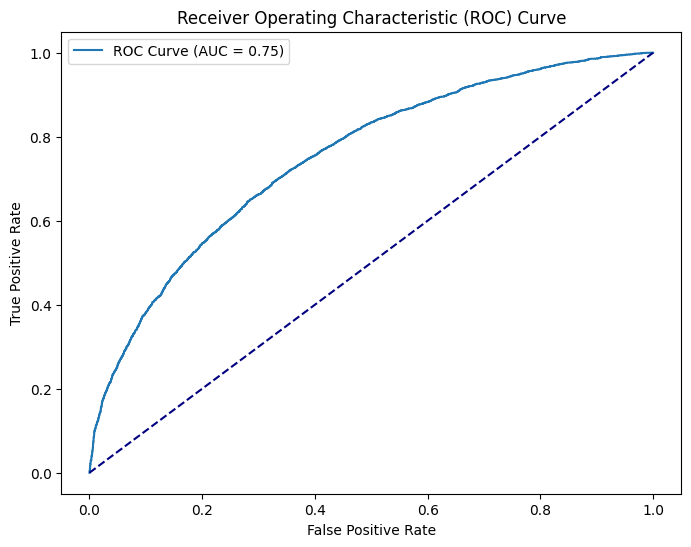

In [ ]:
gb_tuned_model, predict_new_data_gb_tuned, gb_predictions_tuned, y_test = classification_pipeline(df_train,
                                                                                                  'Default',
                                                                                                  cat_cols,
                                                                                                  GradientBoostingClassifier(random_state=42,
                                                                                                                                     n_estimators=300,
                                                                                                                                     learning_rate=0.1,
                                                                                                                                     max_depth=5,
                                                                                                                                     min_samples_leaf=2))

Cross-Validation Accuracy Scores: [0.68173675 0.67594056 0.67825904 0.6820529  0.67169056]
Mean Cross-Validation Accuracy: 0.6779359614407523
Test Accuracy: 0.6826842016523352

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68      5931
           1       0.68      0.69      0.69      5931

    accuracy                           0.68     11862
   macro avg       0.68      0.68      0.68     11862
weighted avg       0.68      0.68      0.68     11862


Confusion Matrix:
[[3983 1948]
 [1816 4115]]


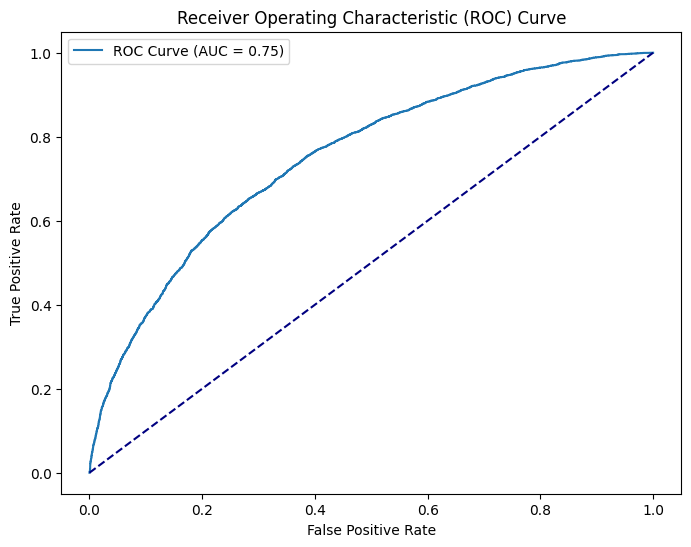

In [ ]:
lr_tuned_model, predict_new_data_lr_tuned, lr_predictions_tuned, y_test = classification_pipeline(df_train,
                                                                                                  'Default',
                                                                                                  cat_cols,
                                                                                                  LogisticRegression(max_iter=1000,
                                                                                                                     C=0.1,
                                                                                                                     penalty='l2',
                                                                                                                     solver='liblinear'))

In [ ]:
test_accuracies = []
tuned_models = [gb_tuned_model, lr_tuned_model, rf_tuned_model]
tuned_predictions = [gb_predictions_tuned, lr_predictions_tuned, rf_predictions_tuned]

for model, pred in zip(tuned_models, tuned_predictions):
  test_accuracies.append(evaluate_model(model, y_test, pred))

Text(0.5, 1.0, 'Model Test Accuracies Comparison After Tuning')

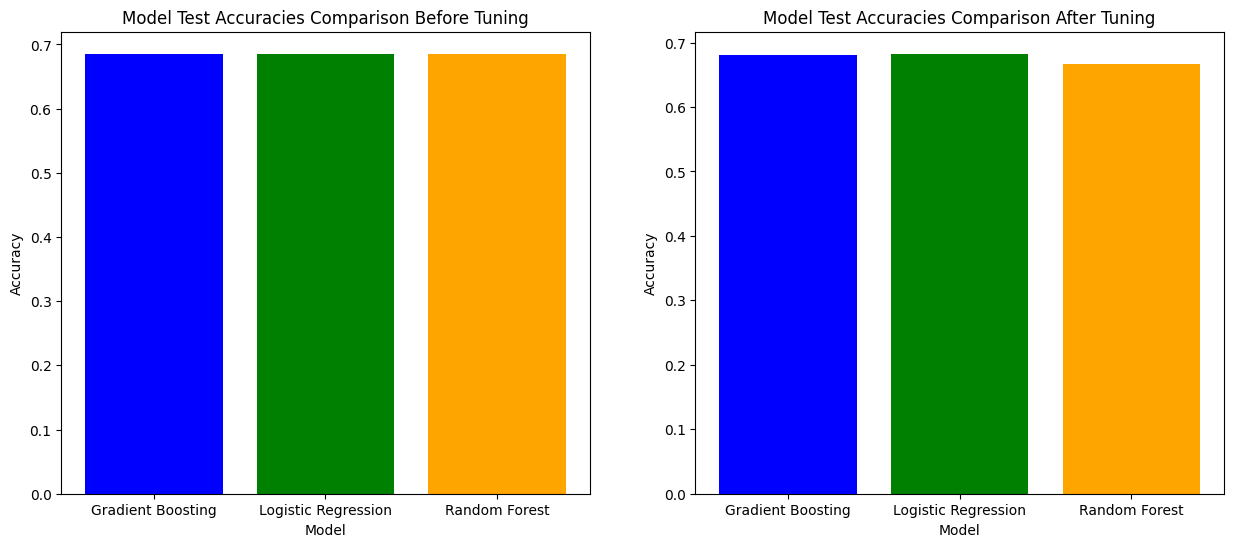

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Test Accuracies Comparison Before Tuning')

plt.subplot(1,2,2)
plt.bar(models, test_accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Test Accuracies Comparison After Tuning')

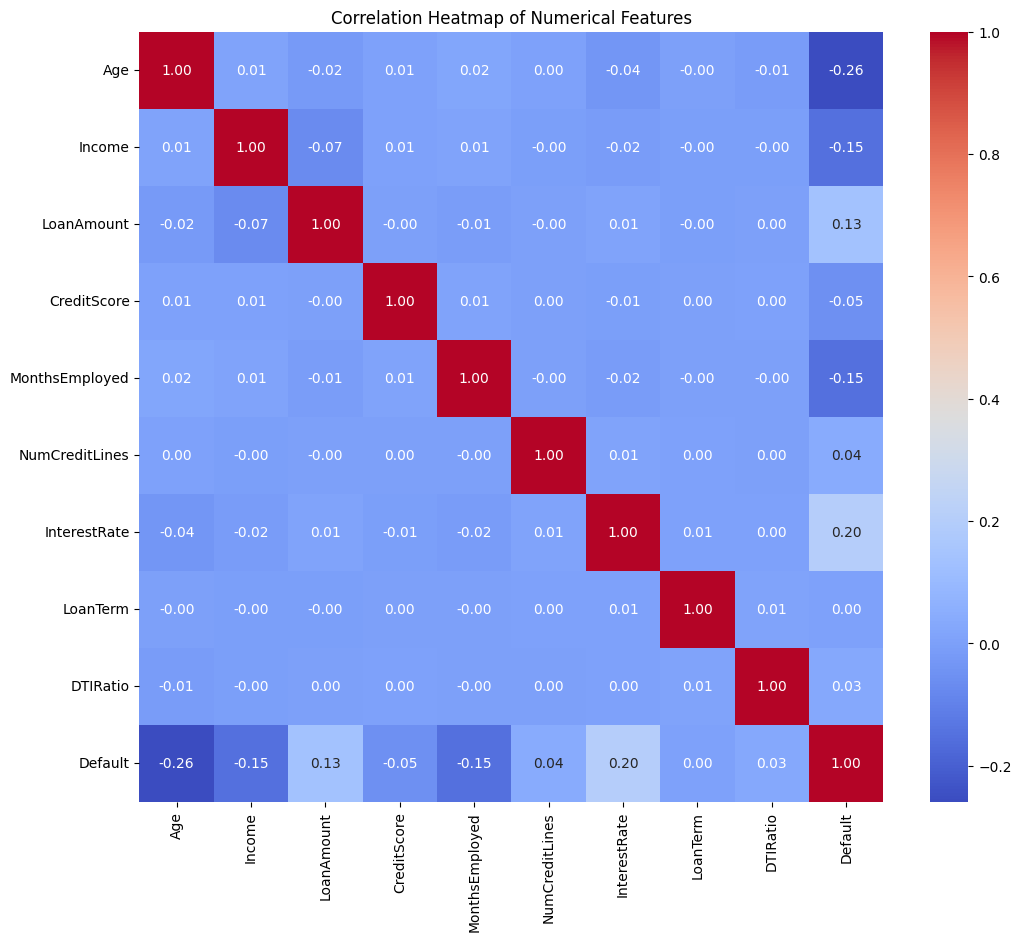

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_train[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Correlation with 'Default'

Let's specifically look at the correlation of each numerical feature with the 'Default' target variable to identify the strongest predictors.

In [ ]:
correlation_with_default = df_train[num_cols].corr()['Default'].sort_values(ascending=False)
display(correlation_with_default)

,Default
Default,1.000000
InterestRate,0.203386
LoanAmount,0.134794
NumCreditLines,0.041272
DTIRatio,0.031457
LoanTerm,0.002924
CreditScore,-0.053217
MonthsEmployed,-0.150696
Income,-0.152573
Age,-0.258553


# Saving the Model

In [ ]:
# import pickle

# def save_model(model, filename):
#   with open(filename, 'wb') as file:
#     pickle.dump(model, file)

In [ ]:
# save_model(model, 'model.pkl')

In [ ]:
# import pandas as pd

# def save_predictions_to_csv(predictions, filename):
#   df = pd.DataFrame({'Predictions': predictions}, index=range(len(predictions)))
#   df.to_csv(filename, index=False)

In [ ]:
# save_predictions_to_csv(predictions, 'predictions.csv')

In [ ]:
# save_predictions_to_csv_2(test_ds, 'test.csv')

In [ ]:
# test_ds = df_train.drop(columns=['Default'])

In [ ]:
# test_ds.to_csv('test_update.csv', index=False)